# 03 — Behaviour × EEG

Lab only, \(n = 18\). EEG is the confirmatory Dataset A \(k=37\) condition aggregation; all 16 features swept, Fz \(\theta\) and posterior \(\alpha\) headline.

Two grains: **D** = person-level planned \(D_i\), same contrast on both sides, Spearman; **RM** = condition-state repeated-measures correlation with the person centred out (Bakdash & Marusich; df = N − k − 1). Association, not mediation. Holm is within `combo × grain × contrast`; BH is across all 2,560 combo tests. **Result: zero Holm-family and zero BH-global hits in this family**; what follows shows the raw landscape so the null is visible, not asserted.

Rebuild: `python analysis/walter/combos/run_combos.py`.

In [1]:
from pathlib import Path
import json, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

HERE = Path.cwd().resolve()
while not (HERE / "analysis" / "walter" / "statkit.py").exists():
    HERE = HERE.parent
WALTER = HERE / "analysis" / "walter"
for p in (WALTER, WALTER / "behavioural" / "stats", WALTER / "combos"):
    sys.path.insert(0, str(p))
import statkit as sk
import viz
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 42)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
GOLD = WALTER / "behavioural" / "outputs" / "gold"
import run_combos as rcb
OUT = rcb.OUT / "beh_eeg"
if not (OUT / "tests.csv").exists():
    rcb.run()
t = pd.read_csv(OUT / "tests.csv")
summ = json.loads((rcb.OUT / "summary.json").read_text())["by_combo"]["beh_eeg"]
print({k: v for k, v in summ.items() if k != "top_raw"})
dtab = pd.read_csv(GOLD / "combo_threeway_lab_D.csv"); state = pd.read_csv(GOLD / "combo_threeway_lab.csv")
RIGHT = ['eeg_fz_theta', 'eeg_posterior_alpha', 'eeg_theta', 'eeg_alpha', 'eeg_beta', 'eeg_delta', 'eeg_gamma', 'eeg_faa', 'eeg_rel_delta', 'eeg_rel_theta', 'eeg_rel_alpha', 'eeg_rel_beta', 'eeg_rel_gamma', 'eeg_engagement', 'eeg_pope', 'eeg_kislov']

{'n_tests': 960, 'n_families': 4, 'hits_raw': 44, 'hits_holm_family': 0, 'hits_bh_global': 0, 'expected_false_raw_at_005': 48.0, 'headline_tests': 32, 'headline_raw_hits': 0}


## 1. D grain, one heatmap per planned contrast (• raw p < .05)

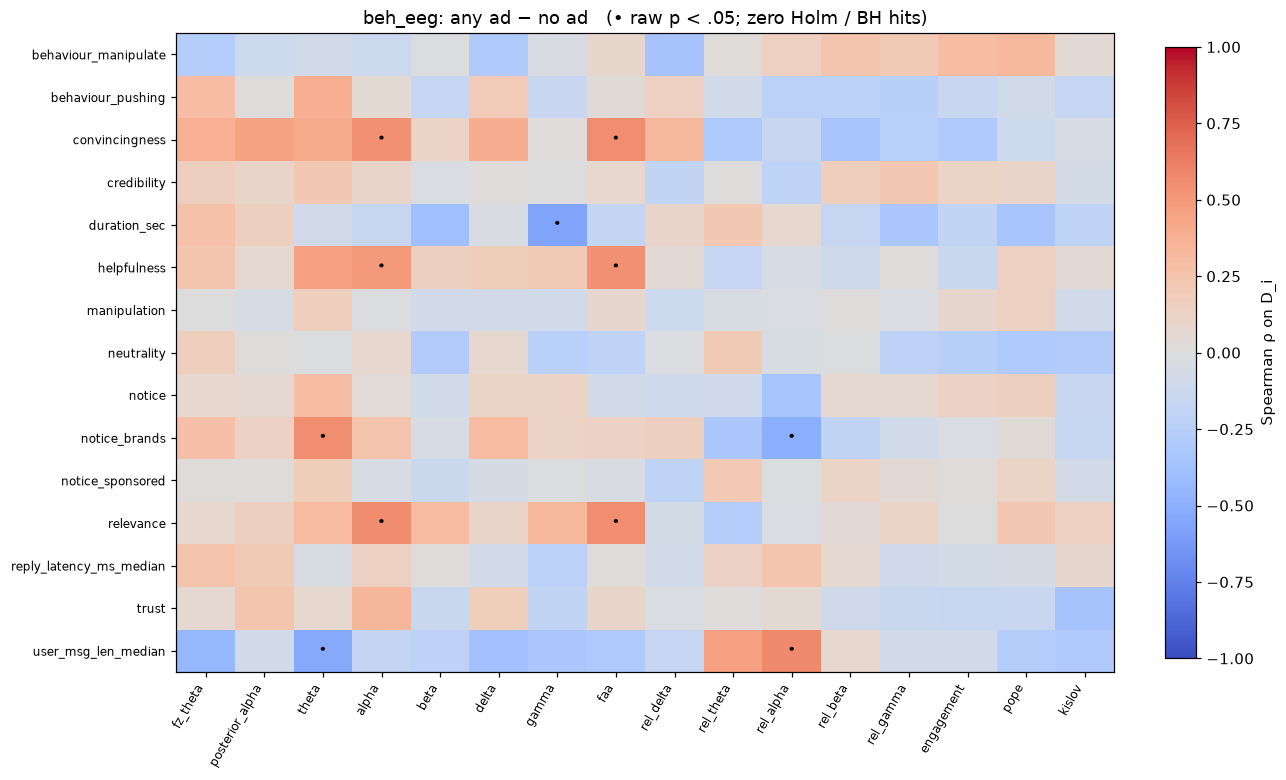

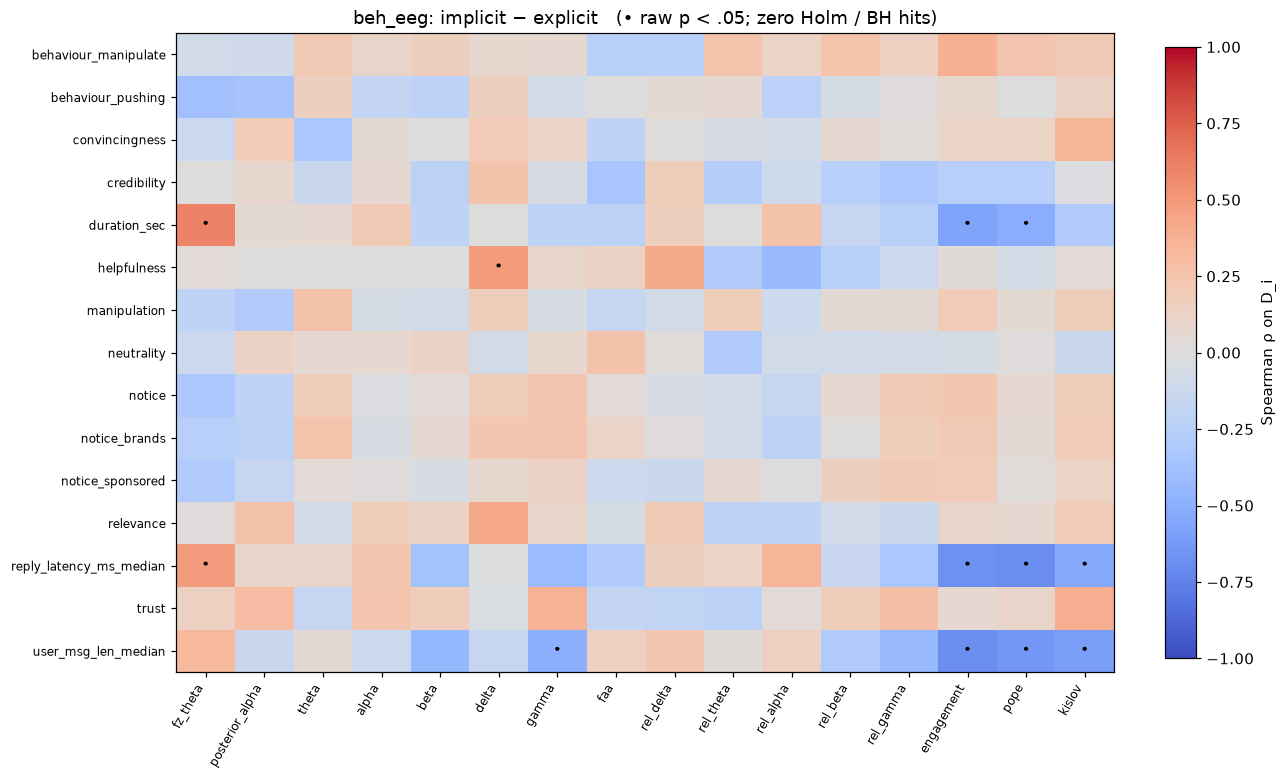

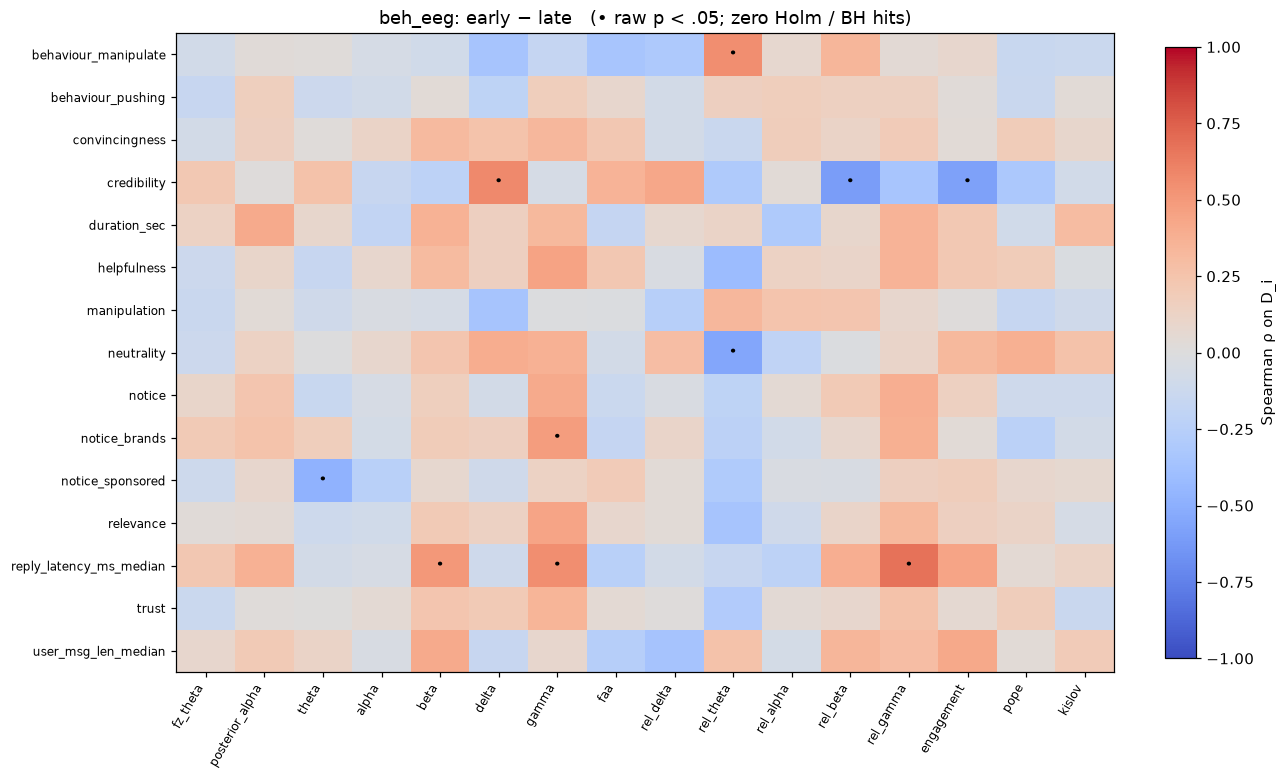

In [2]:
for cid in sk.PLANNED:
    display(viz.combo_heat(t, "beh_eeg", cid, RIGHT)); plt.close()

## 2. Headline cells (primary behaviour / trajectory × headline partner)

In [3]:
h = pd.read_csv(OUT / "tests_headline.csv")
cols = [x for x in ["grain", "contrast_label", "left", "right", "n", "n_persons", "effect", "effect_name", "p_raw", "p_holm_family", "p_bh_global"] if x in h.columns]
display(h.sort_values("p_raw")[cols].head(15).round(4))

,grain,contrast_label,left,right,n,n_persons,effect,effect_name,p_raw,p_holm_family,p_bh_global
0,D,implicit − explicit,notice,eeg_fz_theta,18.0,NaN,-0.3144,Spearman rho,0.2039,1.0,0.9958
1,D,implicit − explicit,trust,eeg_posterior_alpha,18.0,NaN,0.2927,Spearman rho,0.2385,1.0,0.9958
2,D,implicit − explicit,manipulation,eeg_posterior_alpha,18.0,NaN,-0.2875,Spearman rho,0.2474,1.0,0.9958
24,RM,"person x condition rows, person centred",credibility,eeg_posterior_alpha,NaN,18.0,0.1237,r_rm,0.2972,1.0,0.9958
25,RM,"person x condition rows, person centred",credibility,eeg_fz_theta,NaN,18.0,0.1157,r_rm,0.3296,1.0,0.9958
3,D,early − late,notice,eeg_posterior_alpha,18.0,NaN,0.2413,Spearman rho,0.3347,1.0,0.9958
4,D,any ad − no ad,trust,eeg_posterior_alpha,18.0,NaN,0.2372,Spearman rho,0.3433,1.0,0.9958
5,D,early − late,credibility,eeg_fz_theta,18.0,NaN,0.2137,Spearman rho,0.3944,1.0,0.9958
26,RM,"person x condition rows, person centred",trust,eeg_posterior_alpha,NaN,18.0,0.1002,r_rm,0.3992,1.0,0.9958
6,D,implicit − explicit,manipulation,eeg_fz_theta,18.0,NaN,-0.2089,Spearman rho,0.4055,1.0,0.9958


## 3. The three lowest raw cells, drawn (so the eye can judge what a raw p ≈ .002 looks like at this n)

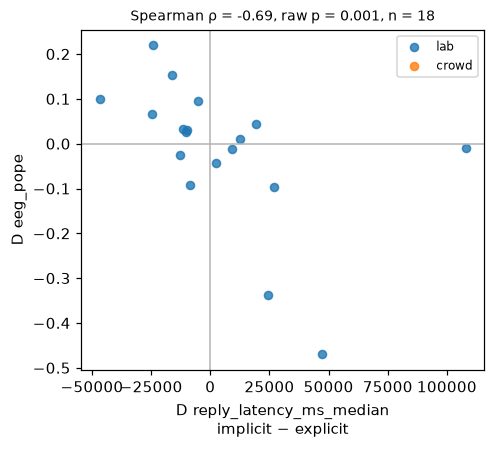

D  reply_latency_ms_median × eeg_pope  implicit − explicit: effect -0.69, raw p 0.0014, Holm 0.35, BH 0.90, family size 240


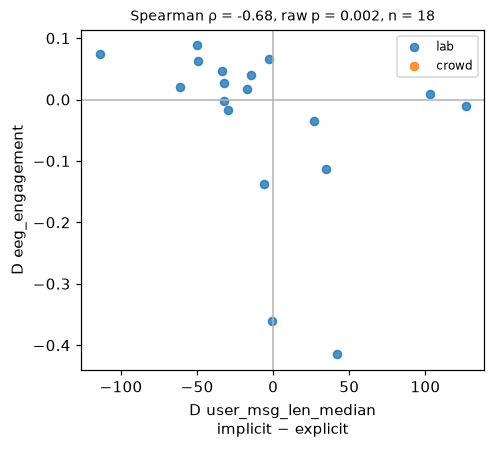

D  user_msg_len_median × eeg_engagement  implicit − explicit: effect -0.68, raw p 0.0019, Holm 0.45, BH 0.90, family size 240


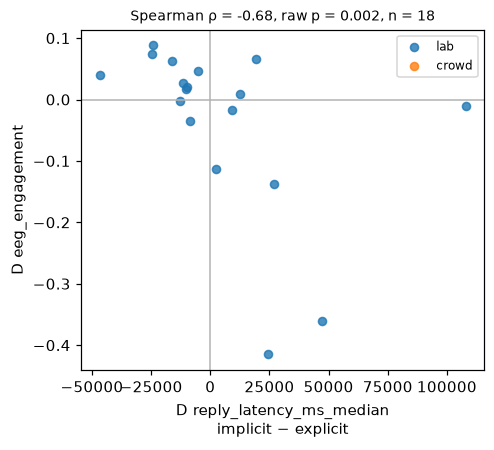

D  reply_latency_ms_median × eeg_engagement  implicit − explicit: effect -0.68, raw p 0.0020, Holm 0.47, BH 0.90, family size 240


In [4]:
top = t.sort_values("p_raw").head(3)
for _, r in top.iterrows():
    if r.grain == "D":
        display(viz.scatter_D(dtab, r.left, r.right, r.contrast)); plt.close()
    else:
        display(viz.rm_plot(state, r.left, r.right)); plt.close()
    print(f"{r.grain}  {r.left} × {r.right}  {r.contrast_label}: effect {r.effect:+.2f}, raw p {r.p_raw:.4f}, Holm {r.p_holm_family:.2f}, BH {r.p_bh_global:.2f}, family size {int(r.n_tests_in_family)}")

## 4. RM grain: the strongest within-person association

In [5]:
rm = t[t.grain == "RM"].sort_values("p_raw").head(8)
display(rm[[x for x in ["left", "right", "n_obs", "n_persons", "dof", "effect", "p_raw", "p_holm_family", "p_bh_global"] if x in rm.columns]].round(4))

,left,right,n_obs,n_persons,dof,effect,p_raw,p_holm_family,p_bh_global
720,user_msg_len_median,eeg_alpha,90.0,18.0,71.0,-0.3464,0.0027,0.644,0.8962
721,user_msg_len_median,eeg_rel_alpha,90.0,18.0,71.0,-0.3057,0.0085,1.000,0.8962
722,behaviour_manipulate,eeg_rel_delta,90.0,18.0,71.0,-0.2904,0.0127,1.000,0.8962
723,relevance,eeg_alpha,90.0,18.0,71.0,0.2649,0.0235,1.000,0.9798
724,duration_sec,eeg_rel_alpha,90.0,18.0,71.0,-0.2601,0.0263,1.000,0.9958
725,reply_latency_ms_median,eeg_rel_alpha,90.0,18.0,71.0,-0.2575,0.0279,1.000,0.9958
726,neutrality,eeg_rel_alpha,90.0,18.0,71.0,-0.2572,0.0280,1.000,0.9958
727,helpfulness,eeg_rel_theta,90.0,18.0,71.0,-0.2409,0.0400,1.000,0.9958


## 5. Raw hits vs chance

raw hits 44 of 960 tests; chance expectation 48; Holm-family 0; BH-global 0


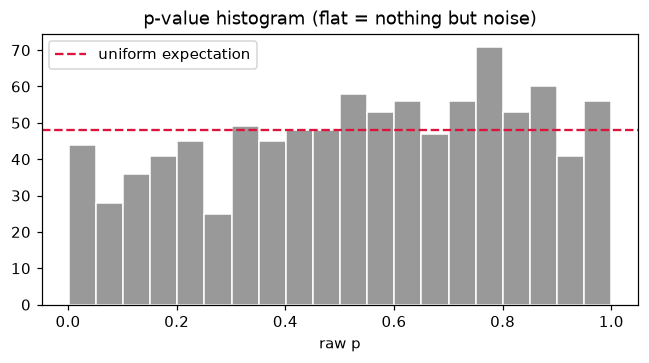

In [6]:
raw = int(t.sig_raw.sum()); print(f"raw hits {raw} of {len(t)} tests; chance expectation {0.05*len(t):.0f}; Holm-family {int(t.sig_holm_family.sum())}; BH-global {int(t.sig_bh_global.sum())}")
fig, ax = plt.subplots(figsize=(7, 3.2)); ax.hist(t.p_raw, bins=20, color="0.6", edgecolor="white"); ax.axhline(len(t)/20, color="crimson", ls="--", label="uniform expectation"); ax.set_xlabel("raw p"); ax.set_title("p-value histogram (flat = nothing but noise)"); ax.legend(); display(fig); plt.close()